## In this Note book we are learn about parallel workflows 

#### Target is building a parallel workflow who calculate Strikerate(SR), Boundry percentege(B%), BoundryPerBall(BPB)

workflow = (START) - ( SR - BP - BPB ) - (summry) - (END)

State = sr = float
bp = float
bpb = float
summary = str




***Note*** - In Parallel workflow as we know In a parallel workflow, all nodes can access the shared state and perform read/write operations. However, we should not pass the entire state to the next node after parallel execution.

This is because multiple nodes may modify the state simultaneously. For example, if three nodes update the same state in parallel, it creates ambiguity about which changes should be retained. The system (such as LangGraph) may throw an error due to conflicting updates, as it cannot determine the correct final state.

Therefore, instead of passing the complete state, we should only pass the specific changes made by each node. This helps avoid conflicts and ensures proper state management in parallel workflows.                      

In [26]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [27]:
# step 1: define the state of the graph
class BatsmanState(TypedDict):
    run: int
    balls: int
    four: int
    six: int

    sr: float
    boundry_percent: float
    bpb: float
    summary: str

In [28]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    sr = (state['run'] / state['balls']) * 100
   
    return {'sr': sr}

In [29]:

def calculate_boundry_percent(state: BatsmanState) -> BatsmanState:
    boundry_percent = ((state['four'] * 4 + state['six'] * 6)) / (state['run'] * 100)
    return {'boundry_percent': boundry_percent}


In [30]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:
    bpb =   state['balls'] / (state['four'] + state['six'])

    return {'bpb': bpb}

In [ ]:
def summary(state: BatsmanState) -> str:
    summry = f"""'str' object has
Strike Rate: {state['sr']}\n
Boundry Percent: {state['boundry_percent']}\n
Balls Per Boundry: {state['bpb']}\n
"""
    
    return {'summary': summry}
  

In [32]:
# step 2: define the graph

graph = StateGraph(BatsmanState)


# step 3: define the nodes of the graph
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_boundry_percent', calculate_boundry_percent)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('summary', summary)

# step 4: add edges — START fans out to all 3 parallel nodes
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_boundry_percent')
graph.add_edge(START, 'calculate_bpb')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_boundry_percent', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('summary', END)



#Step4: compile to your graph just for check graph structure
workflow = graph.compile()



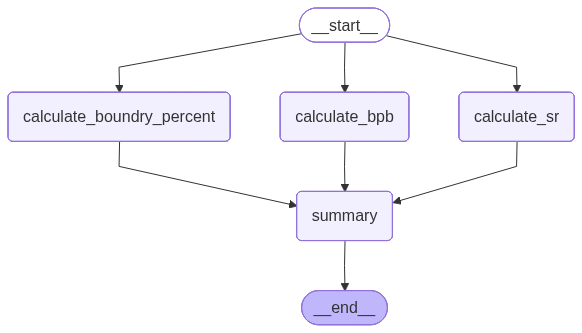

In [33]:
workflow

In [34]:
initial_state = {
    'run': 120,
    'balls': 100,
    'four': 10,
    'six': 5
}

final_state = workflow.invoke(initial_state)
print(final_state['summary'])

'str' object has
Strike Rate: 120.0

Boundry Percent: 0.005833333333333334

Balls Per Boundry: 6.666666666666667


